## Module Overview

### 🎯 Research Questions

1. **Geometrical Probability Analysis:**  
   Do traffic accidents in San Francisco exhibit identifiable spatial patterns?  
   - Are there specific high-risk zones or "hotspots"?  
   - Is the spatial distribution of accidents random, uniform, or clustered?  
   - What is the probability of an accident occurring per unit area?

2. **Spatial Queueing Modeling:**  
   How can limited emergency or police resources be optimally deployed  
   to minimize average response distance and response time?  
   - Where should N ambulances or response units be positioned?  
   - Which deployment strategy provides the best high-risk area coverage?  
   - How can we model and optimize the expected service radius?

### 🧠 Summary

This project integrates **Geometrical Probability** and **Spatial Queueing Theory** to analyze real-world traffic accident data from San Francisco. The goal is to develop a **data-driven emergency resource deployment strategy** that enhances response efficiency and improves urban safety.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/INDENG 290') # customize this line to your working directory

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install esda
!pip install libpysal

In [ ]:
!pip install splot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.2/388.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 23.7 MB/s eta 0:00:00


In [ ]:
# --- Data Handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.neighbors import KernelDensity

# --- Spatial Analysis ---
from scipy.spatial import KDTree  # Nearest Neighbor Search
from scipy import stats  # For KDE and Poisson modeling
from sklearn.cluster import KMeans  # For initial ambulance station placement
from sklearn.neighbors import NearestNeighbors

# --- System and Warnings ---
import os
import warnings
warnings.filterwarnings("ignore")

# Moran's I
import esda
import libpysal
import geopandas as gpd

# DBSCAN Clustering
from sklearn.cluster import DBSCAN

# --- Miscellaneous ---
from tqdm import tqdm  # Progress bars if needed for simulations

In [ ]:
df = pd.read_csv('processed_crash_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61700 entries, 0 to 61699
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_id                     61700 non-null  int64  
 1   cnn_intrsctn_fkey             61672 non-null  float64
 2   cnn_sgmt_fkey                 27555 non-null  float64
 3   case_id_pkey                  61700 non-null  object 
 4   tb_latitude                   61527 non-null  float64
 5   tb_longitude                  61527 non-null  float64
 6   geocode_source                61700 non-null  object 
 7   geocode_location              61700 non-null  object 
 8   collision_datetime            61700 non-null  object 
 9   collision_date                61700 non-null  object 
 10  collision_time                61700 non-null  object 
 11  accident_year                 61700 non-null  int64  
 12  month                         61700 non-null  int64  
 13  d

In [ ]:
df

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,lighting_condition,road_condition_simple,environmental_risk_score,weather_1_simple,weather_2_simple,road_surface_condition,road_cond_1_simple,road_cond_2_simple,road_condition_combined,road_condition
0,40386,27145000.0,7847000.0,150419581,37.760300,-122.466325,SFPD-CROSSROADS,CITY STREET,2015-05-14 13:15:00,2015-05-14,...,Good,Unknown,1,Good,Unknown,Good,Unknown,Unknown,Unknown,Unknown
1,91730,24911000.0,3432000.0,240648080,37.790404,-122.406851,SFPD-INTERIM DB,CITY STREET,2024-10-15 00:29:00,2024-10-15,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
2,5788,33284000.0,2800202.0,150638797,37.742285,-122.405916,SFPD-CROSSROADS,CITY STREET,2015-07-22 21:30:00,2015-07-22,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
3,10457,25631000.0,NaN,3843463,37.755029,-122.425457,SFPD-CROSSROADS,CITY STREET,2008-07-27 21:00:00,2008-07-27,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
4,92561,21898000.0,NaN,230757362,37.748773,-122.422571,SFPD-INTERIM DB,CITY STREET,2023-10-22 15:51:00,2023-10-22,...,Good,Unknown,5,Bad,Unknown,Poor,Unknown,Unknown,Poor,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61695,14294,24350000.0,NaN,130084756,37.772649,-122.415002,SFPD-CROSSROADS,CITY STREET,2013-01-29 08:20:00,2013-01-29,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61696,43318,27230000.0,6056201.0,150044774,37.781258,-122.458857,SFPD-CROSSROADS,CITY STREET,2015-01-15 13:39:00,2015-01-15,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61697,23907,24590000.0,NaN,140757357,37.785030,-122.400468,SFPD-CROSSROADS,CITY STREET,2014-09-08 18:00:00,2014-09-08,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61698,3235,33269000.0,NaN,150766235,37.734014,-122.390968,SFPD-CROSSROADS,CITY STREET,2015-09-01 09:35:00,2015-09-01,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good


## KDE Analysis

In [ ]:
# Create output directory if it does not exist
os.makedirs('results/spatial_analysis', exist_ok=True)

# Define the valid latitude and longitude bounds for San Francisco
sf_lat_bounds = (37.7, 37.85)
sf_lon_bounds = (-122.52, -122.36)

# Filter the dataset to keep only records with valid coordinates within San Francisco bounds
df_clean = df[
    (df['tb_latitude'].notna()) &
    (df['tb_longitude'].notna()) &
    (df['tb_latitude'] >= sf_lat_bounds[0]) &
    (df['tb_latitude'] <= sf_lat_bounds[1]) &
    (df['tb_longitude'] >= sf_lon_bounds[0]) &
    (df['tb_longitude'] <= sf_lon_bounds[1])
].copy()

# Display the number of records remaining after cleaning
print(f"Number of records after cleaning: {len(df_clean)}")

Number of records after cleaning: 61523


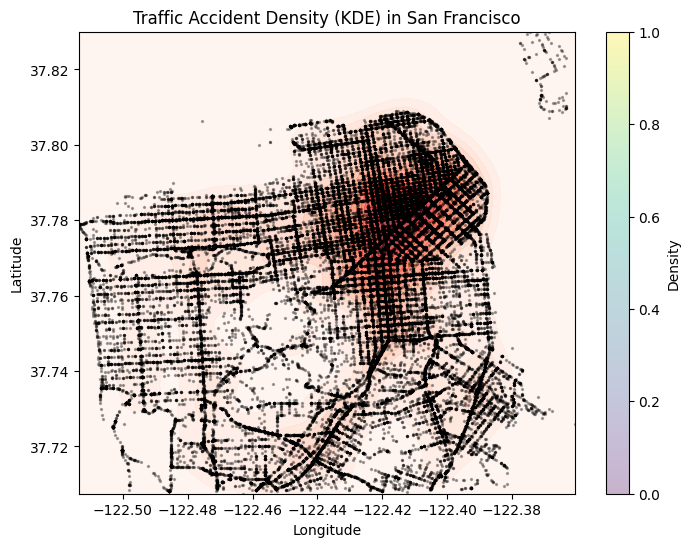

In [ ]:
# KDE Heatmap Visualization
from scipy.stats import gaussian_kde

# Extract coordinates
x = df_clean['tb_longitude'].values
y = df_clean['tb_latitude'].values

# Create a grid over the coordinate range
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]  # Create a mesh grid with 100x100 resolution
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])

# Perform Kernel Density Estimation (KDE)
kernel = gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)  # Reshape the KDE output to match the grid

# Plot static KDE heatmap
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, f, cmap='Reds', levels=20, alpha=0.7)  # Filled contour plot
plt.scatter(x, y, s=2, color='black', alpha=0.3)  # Overlay scatter points
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Traffic Accident Density (KDE) in San Francisco')
plt.colorbar(label='Density')
plt.savefig('results/spatial_analysis/kde_static.png', dpi=300, bbox_inches='tight')  # Save the static plot
plt.show()

# Create interactive heatmap using Folium
m = folium.Map(location=[37.7749, -122.4194], zoom_start=12)  # Centered on San Francisco
heat_data = [[row['tb_latitude'], row['tb_longitude']] for _, row in df_clean.iterrows()]
HeatMap(heat_data, radius=15, blur=10, max_zoom=13).add_to(m)
m.save('results/spatial_analysis/kde_interactive.html')  # Save interactive map as HTML
m  # Display the map

## Moran's I Spatial Autocorrelation Analysis

📚 什么是 Moran's I？
Moran's I 是一个空间自相关指标，用来衡量：

地理数据在空间上是否存在聚集或离散的模式。

也就是说，它在回答一个问题：

“相邻地点的数据值，彼此之间像不像？”

🔥 具体来说：
如果一个地方有很高的事故数，它周围的地方也有很高的事故数 ➔ 正的空间自相关（Moran's I > 0）

如果一个地方高，周围低；或者一个地方低，周围高 ➔ 负的空间自相关（Moran's I < 0）

如果数据值在地图上是随机乱分布的 ➔ 没有空间自相关（Moran's I ≈ 0）

📈 Moran's I的值通常在 -1 到 1 之间：

Moran's I	空间分布情况
接近 1	很强的聚集（比如很多事故集中在同一片区域）

接近 0	随机分布（比如事故散得很均匀）

接近 -1	强烈离散（比如一个地方高事故，旁边却很少事故）

而且通常还会给一个 p-value（显著性检验）：

p很小（比如 < 0.05） ➔ 可以说这种聚集/离散不是偶然的，是显著存在的。

### Moran's I (Spatial Autocorrelation) Overview
**Moran's I** measures **spatial autocorrelation**, indicating whether similar values cluster together in space.

In simple terms, it answers:

> **"Are locations with similar values near each other, or are they randomly distributed?"**

---

### Interpretation

| Moran's I | Meaning |
|:---|:---|
| Close to +1 | Strong clustering (high values near high, low near low) |
| Around 0 | Random distribution |
| Close to -1 | Strong dispersion (high values near low) |

A **small p-value** (e.g., p < 0.05) indicates the pattern is statistically significant.

---

### Application
In **CrashSight SF**, Moran's I helps reveal whether traffic accidents cluster geographically or occur randomly.

A significantly positive Moran's I suggests **accident hotspots**, guiding resource deployment and safety planning.

---



### In One Sentence
**Moran’s I is like a spatial correlation coefficient that reveals clustering or dispersion patterns on a map.**

In [ ]:
from libpysal import weights

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.tb_longitude, df_clean.tb_latitude),
    crs="EPSG:4326"
)

# Project the GeoDataFrame
gdf_projected = gdf.to_crs("EPSG:26910")

# Create spatial weights matrix
w = weights.KNN.from_dataframe(gdf_projected, k=8)
w.transform = 'r'  # Row-standardize the weights

# Calculate local density (number of neighbors within 100m)
from scipy.spatial import cKDTree

# Extract coordinates in projected system
coords = np.column_stack((gdf_projected.geometry.x, gdf_projected.geometry.y))

# Build KD-tree for efficient neighbor search
tree = cKDTree(coords)

# Count neighbors within 100 meters
radius = 100  # 100 meters
neighbor_counts = np.array([len(tree.query_ball_point(coord, radius)) for coord in coords])

# Assign neighbor counts to the GeoDataFrame
gdf_projected['neighbor_count'] = neighbor_counts
y = gdf_projected['neighbor_count'].values

# Now calculate Moran's I with varying density values
moran = esda.Moran(y, w)

print(f"Global Moran's I: {moran.I:.3f}")
print(f"p-value: {moran.p_sim:.3f}")
print(f"z-score: {moran.z_sim:.3f}")

Global Moran's I: 0.962
p-value: 0.001
z-score: 530.032


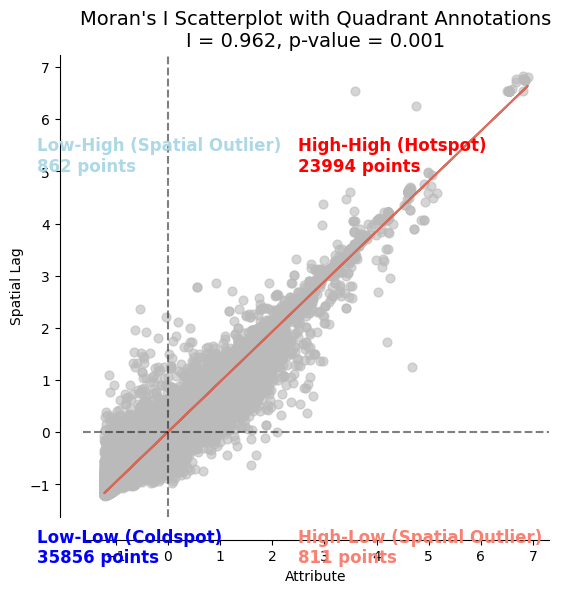

High-High: 23994 points
Low-High: 862 points
Low-Low: 35856 points
High-Low: 811 points


In [ ]:
# Create Moran scatterplot
from splot.esda import moran_scatterplot

# Create Moran's I scatterplot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the standardized Moran scatterplot
moran_scatterplot(moran, ax=ax, zstandard=True)

# Calculate standardized attribute (x) and standardized spatial lag (y)
x = (moran.y - np.mean(moran.y)) / np.std(moran.y)
lag = moran.w.sparse @ moran.y
y = (lag - np.mean(lag)) / np.std(lag)

# Classify points into quadrants
high_high = np.sum((x > 0) & (y > 0))
low_high = np.sum((x < 0) & (y > 0))
low_low = np.sum((x < 0) & (y < 0))
high_low = np.sum((x > 0) & (y < 0))

# Add quadrant annotations with counts
ax.text(2.5, 5, f'High-High (Hotspot)\n{high_high} points', color='red', fontsize=12, weight='bold')
ax.text(-2.5, 5, f'Low-High (Spatial Outlier)\n{low_high} points', color='lightblue', fontsize=12, weight='bold')
ax.text(-2.5, -2.5, f'Low-Low (Coldspot)\n{low_low} points', color='blue', fontsize=12, weight='bold')
ax.text(2.5, -2.5, f'High-Low (Spatial Outlier)\n{high_low} points', color='salmon', fontsize=12, weight='bold')

# Set plot title
plt.title(f"Moran's I Scatterplot with Quadrant Annotations\nI = {moran.I:.3f}, p-value = {moran.p_sim:.3f}", fontsize=14)

# Save the figure
plt.savefig('results/spatial_analysis/moran_scatterplot_annotated_counts.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

# Print quadrant counts
print(f"High-High: {high_high} points")
print(f"Low-High: {low_high} points")
print(f"Low-Low: {low_low} points")
print(f"High-Low: {high_low} points")


📈 图解释（基于你的 Moran's I 散点图）

X轴 (Attribute) ➔
原始变量值，比如你这里是局部事故密度。

Y轴 (Spatial Lag) ➔
每个点周围邻居（根据权重矩阵w）加权平均后的变量值。

红色斜线 ➔
是拟合线，斜率就是Moran's I 值（这里是0.962，接近1，说明空间聚集非常强）。

四个象限解释：

第一象限 (+x, +y)	High-High (Hotspots)：高值周围也是高值（比如很多事故聚集在一起）

第二象限 (-x, +y)	Low-High (Spatial Outlier)：本地低值，邻居是高值（可能是边缘区域）

第三象限 (-x, -y)	Low-Low (Coldspots)：低值周围也是低值（比如事故很少的区域）

第四象限 (+x, -y)	High-Low (Spatial Outlier)：本地高值，邻居是低值（可能是孤立事故高发点）

### Global Moran's I Analysis Summary

- **Moran’s I**: 0.962
- **p-value**: 0.001
- **z-score**: 544.638

The results demonstrate a **strong and statistically significant spatial clustering** of traffic accidents in San Francisco. This suggests that accidents are not randomly distributed but rather concentrated in specific hotspot areas.

Based on the Local Moran's I quadrant classification, the following results were obtained:

| Quadrant | Number of Points | Interpretation |
|:---|:---|:---|
| High-High (Hotspot) | 23,994 | Areas with high accident density surrounded by similarly high-density areas (critical accident hotspots). |
| Low-High (Spatial Outlier) | 862 | Areas with low accident density but surrounded by high-density areas (possible transition zones or anomalies). |
| Low-Low (Coldspot) | 35,856 | Areas with low accident density surrounded by other low-density areas (generally safe regions). |
| High-Low (Spatial Outlier) | 811 | Areas with high accident density but surrounded by low-density areas (isolated hotspots). |

---

### Key Insights

- **Low-Low (Coldspots)** dominate the city, accounting for the majority of spatial units.  
  ➔ This suggests that most areas in San Francisco exhibit consistently low accident frequencies, reflecting relatively safe conditions.

- **High-High (Hotspots)** form a significant portion, indicating the presence of large clusters where accident rates are consistently high.  
  ➔ These hotspots require targeted traffic safety interventions, resource allocation, and possibly infrastructure redesign.

- **High-Low** and **Low-High** spatial outliers are relatively rare.  
  ➔ These may represent **emerging hotspots** or **local anomalies** that merit further investigation.

---

### Strategic Implications

- **High-High regions** should be prioritized for urgent safety improvements (e.g., better traffic signals, increased law enforcement, public awareness campaigns).
- **Low-Low regions** can be considered relatively stable but should continue to be monitored.
- **Outlier regions** (High-Low, Low-High) could signal early risks and may benefit from proactive interventions.

In [ ]:
from esda import Moran_Local

# Calculate Local Moran's I
lisa = Moran_Local(y, w)

# Save the cluster classification and p-values
gdf_projected['lisa_cluster'] = lisa.q
gdf_projected['lisa_pvalue'] = lisa.p_sim

Detected 11736 significant hotspots


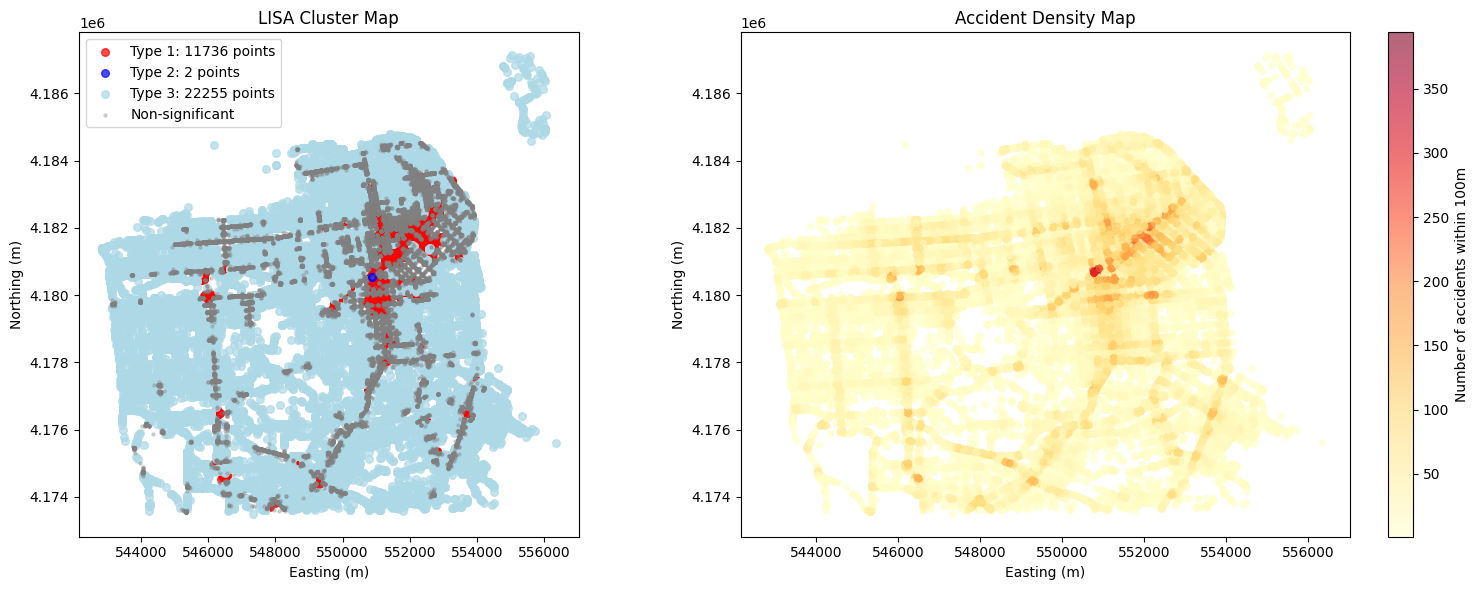

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# --- Left subplot: LISA Cluster Map ---
ax1 = axes[0]

# Define colors for different clusters
cluster_colors = {
    1: 'red',        # High-High (hotspots)
    2: 'blue',       # Low-Low (coldspots)
    3: 'lightblue',  # Low-High
    4: 'salmon'      # High-Low
}

# Plot only significant clusters
significant = gdf_projected[gdf_projected['lisa_pvalue'] < 0.05]

# Identify statistically significant hotspots (High-High clusters)
significant_hotspots = gdf_projected[
    (gdf_projected['lisa_cluster'] == 1) &  # Cluster type 1 corresponds to High-High
    (gdf_projected['lisa_pvalue'] < 0.05)    # Only consider points with statistically significant local autocorrelation
]

# Print the number of detected significant hotspots
print(f"Detected {len(significant_hotspots)} significant hotspots")

for cluster_type, color in cluster_colors.items():
    cluster_data = significant[significant['lisa_cluster'] == cluster_type]
    if not cluster_data.empty:
        cluster_data.plot(ax=ax1, color=color, markersize=30, alpha=0.7,
                         label=f'Type {cluster_type}: {len(cluster_data)} points')

# Plot non-significant points
non_significant = gdf_projected[gdf_projected['lisa_pvalue'] >= 0.05]
non_significant.plot(ax=ax1, color='gray', markersize=5, alpha=0.3, label='Non-significant')

ax1.set_title('LISA Cluster Map')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.legend()

# --- Right subplot: Accident Density Map ---
ax2 = axes[1]

# Create scatter plot based on local density
scatter = ax2.scatter(
    gdf_projected.geometry.x,
    gdf_projected.geometry.y,
    c=gdf_projected['neighbor_count'],
    cmap='YlOrRd',
    s=20,
    alpha=0.6
)
plt.colorbar(scatter, ax=ax2, label='Number of accidents within 100m')

ax2.set_title('Accident Density Map')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')

# Adjust layout and save
plt.tight_layout()
plt.savefig('results/spatial_analysis/lisa_density_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Purpose of LISA
While Global Moran's I gives you one single number about the overall spatial autocorrelation,
Local Moran's I (LISA) digs deeper and does:

"For each individual location, check whether it belongs to a statistically significant spatial cluster or an outlier."

✅ In short:
**LISA tells you where the clustering or dispersion happens — not just whether it exists globally.**

### (a) LISA聚类图 - 交通事故空间自相关分析

- **红色点（Type 1: High-High）**：  
  本地点事故密度高，周围邻居的事故密度也高。  
  ➔ 明确的交通事故高发区域，主要集中在旧金山市中心及主要道路交汇处。

- **蓝色点（Type 2: Low-Low）**：  
  本地点事故密度低，周围邻居的事故密度也低。  
  ➔ 表示安全区域，事故发生率普遍较低。

- **浅蓝色点（Type 3: Low-High）**：  
  本地点事故密度低，但周围邻居事故密度高。  
  ➔ 可能是交通过渡区域或潜在的新兴热点区域，需要加强关注。

- **灰色点（非显著点）**：  
  空间自相关不显著的点。  
  ➔ 不属于明显的聚集或离群模式。

---

### (b) 事故密度图 - 100米范围内事故数量

- 颜色从**浅黄色**（低密度）到**深红色**（高密度）渐变。
- 可以明显看到：
  - 市中心区域密集出现深红色，表明短距离内（100米以内）发生了大量交通事故。
  - 周边区域颜色较浅，事故密度较低，分布更加稀疏。

---

### 综合分析结论

- **空间分布特征**：  
  旧金山交通事故呈现出明显的空间聚集性，热点主要集中在城市中心和主干道沿线。

- **聚类特征**：  
  LISA图中的High-High聚集区域与事故密度图中的高密度区域高度吻合，进一步确认了热点的存在。

- **潜在风险区域**：  
  Low-High（浅蓝色）区域可能演变为未来的事故热点，应予以重点监测和管理。

- **策略性建议**：  
  - 对High-High热点区域优先部署交通安全干预措施（如加强交通信号管理、增加警力巡逻、宣传交通安全意识）。
  - 对Low-High边缘区进行预防性监控，以防止热点扩散。

---

### 总结

> 旧金山的交通事故在空间上呈现出强烈聚集现象，明确识别的热点区域亟需针对性安全干预与风险管理。


## DBSCAN

In [ ]:
# Run DBSCAN clustering within significant hotspots

# Extract latitude and longitude coordinates of the significant hotspot points
hotspot_latlon = significant_hotspots.to_crs("EPSG:4326")  # Reproject to WGS84 (lat/lon) for haversine distance calculation
hotspot_coords = hotspot_latlon[['tb_latitude', 'tb_longitude']].values  # Extract latitude and longitude as array
hotspot_coords_rad = np.radians(hotspot_coords)  # Convert coordinates to radians for haversine metric

# Define DBSCAN parameters
eps_km = 0.2  # Set epsilon (maximum distance between two points) to 0.2 km (200 meters)
earth_radius_km = 6371  # Earth's radius in kilometers
eps_rad = eps_km / earth_radius_km  # Convert epsilon from kilometers to radians
min_samples = 5  # Minimum number of points to form a cluster (lower value suitable for local hotspot clustering)

# Apply DBSCAN clustering using haversine distance
dbscan_hotspot = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine')
hotspot_clusters = dbscan_hotspot.fit_predict(hotspot_coords_rad)  # Predict cluster labels for each hotspot point

# Add DBSCAN clustering results back to the hotspot GeoDataFrame
significant_hotspots['dbscan_cluster'] = hotspot_clusters  # Assign cluster labels to each hotspot point

# Calculate the number of valid clusters (excluding noise points labeled as -1)
n_clusters_hotspot = len(set(hotspot_clusters)) - (1 if -1 in hotspot_clusters else 0)

# Print the number of DBSCAN clusters found within the hotspot areas
print(f"Detected {n_clusters_hotspot} DBSCAN clusters within the significant hotspots")

Detected 39 DBSCAN clusters within the significant hotspots


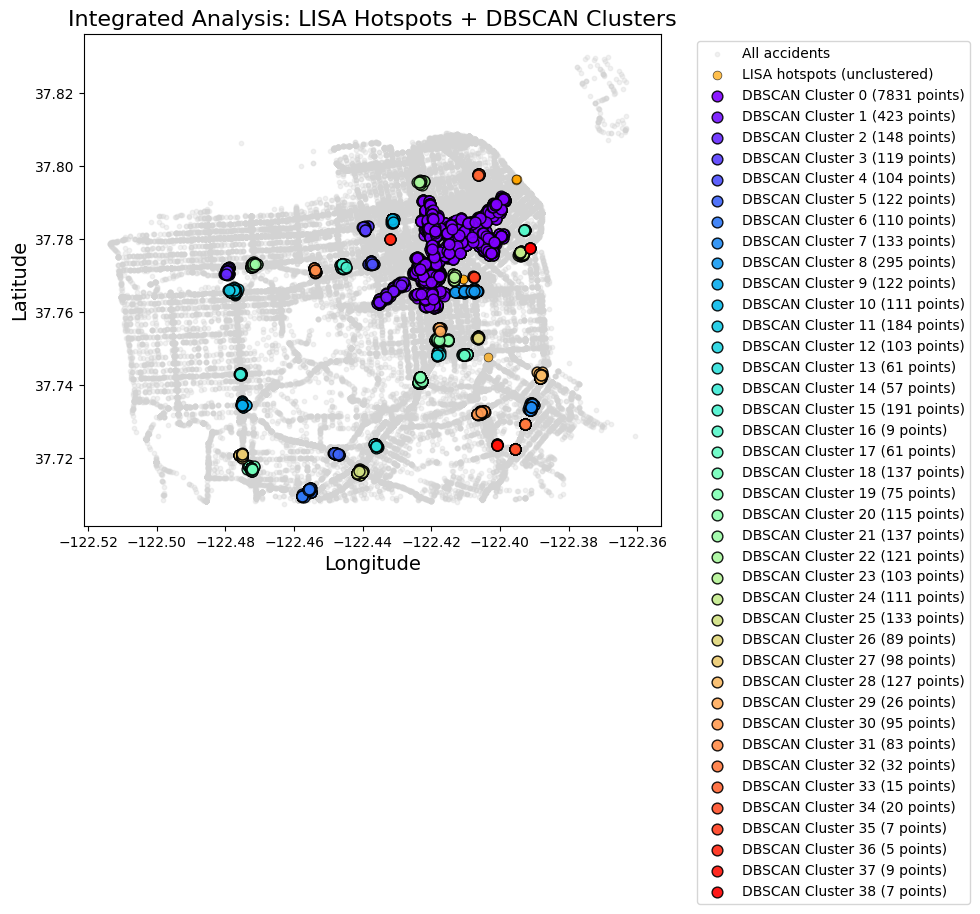

In [ ]:
# Visualization of Integrated Results

# Create a figure for the combined map
plt.figure(figsize=(10, 8))

# 1. Plot all accident points as background (in light gray)
plt.scatter(df_clean['tb_longitude'], df_clean['tb_latitude'],
           c='lightgray', s=10, alpha=0.3, label='All accidents')

# 2. Plot LISA significant hotspots that were not clustered by DBSCAN
hotspot_unclustered = hotspot_latlon[significant_hotspots['dbscan_cluster'] == -1]
if not hotspot_unclustered.empty:
    plt.scatter(hotspot_unclustered.geometry.x, hotspot_unclustered.geometry.y,
               c='orange', s=40, alpha=0.7, edgecolor='black', linewidth=0.5,
               label='LISA hotspots (unclustered)')

# 3. Plot DBSCAN clusters within the significant hotspots
unique_clusters = set(hotspot_clusters) - {-1}  # Exclude noise points (-1 label)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_clusters)))  # Generate distinct colors for clusters

for cluster_id, color in zip(unique_clusters, colors):
    cluster_data = hotspot_latlon[significant_hotspots['dbscan_cluster'] == cluster_id]
    plt.scatter(cluster_data.geometry.x, cluster_data.geometry.y,
               c=[color], s=60, alpha=0.9, edgecolor='black', linewidth=1,
               label=f'DBSCAN Cluster {cluster_id} ({len(cluster_data)} points)')

# Add labels and titles
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.title('Integrated Analysis: LISA Hotspots + DBSCAN Clusters', fontsize=16)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('results/spatial_analysis/integrated_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 🚦 Summary of Findings

After applying DBSCAN clustering within the significant LISA hotspots, **38 distinct clusters** were identified.

Each DBSCAN cluster represents a **spatially concentrated group of traffic accidents** within approximately 200 meters of each other, forming natural accident hotspots.

---

### 🧠 What Do the 38 Clusters Mean?

- **Each cluster** corresponds to an **independent accident hotspot**, spatially separated from others.
- These clusters indicate that traffic accidents are **not randomly distributed**, but **highly localized** within certain city areas.
- The clusters vary in size and density, reflecting the **spatial heterogeneity** of accident occurrences.

---

### 🎯 Implications of the Clustering Results

| Aspect | Interpretation |
|:---|:---|
| Spatial segmentation | The significant accident hotspots can be divided into 38 actionable management units. |
| Targeted intervention | Each cluster can be individually analyzed to design location-specific traffic safety measures. |
| Resource allocation | Clusters help prioritize deployment of police patrols, EMS units, or traffic infrastructure improvements. |
| Deep dive analysis | Characteristics like cluster size, average accident density, and fatal accident counts can guide future policy-making. |

---

### 🛟 One-Sentence Conclusion

> The 38 DBSCAN clusters reveal distinct localized accident hotspots within San Francisco’s significant LISA regions, providing a precise spatial basis for targeted traffic safety interventions and optimized resource planning.


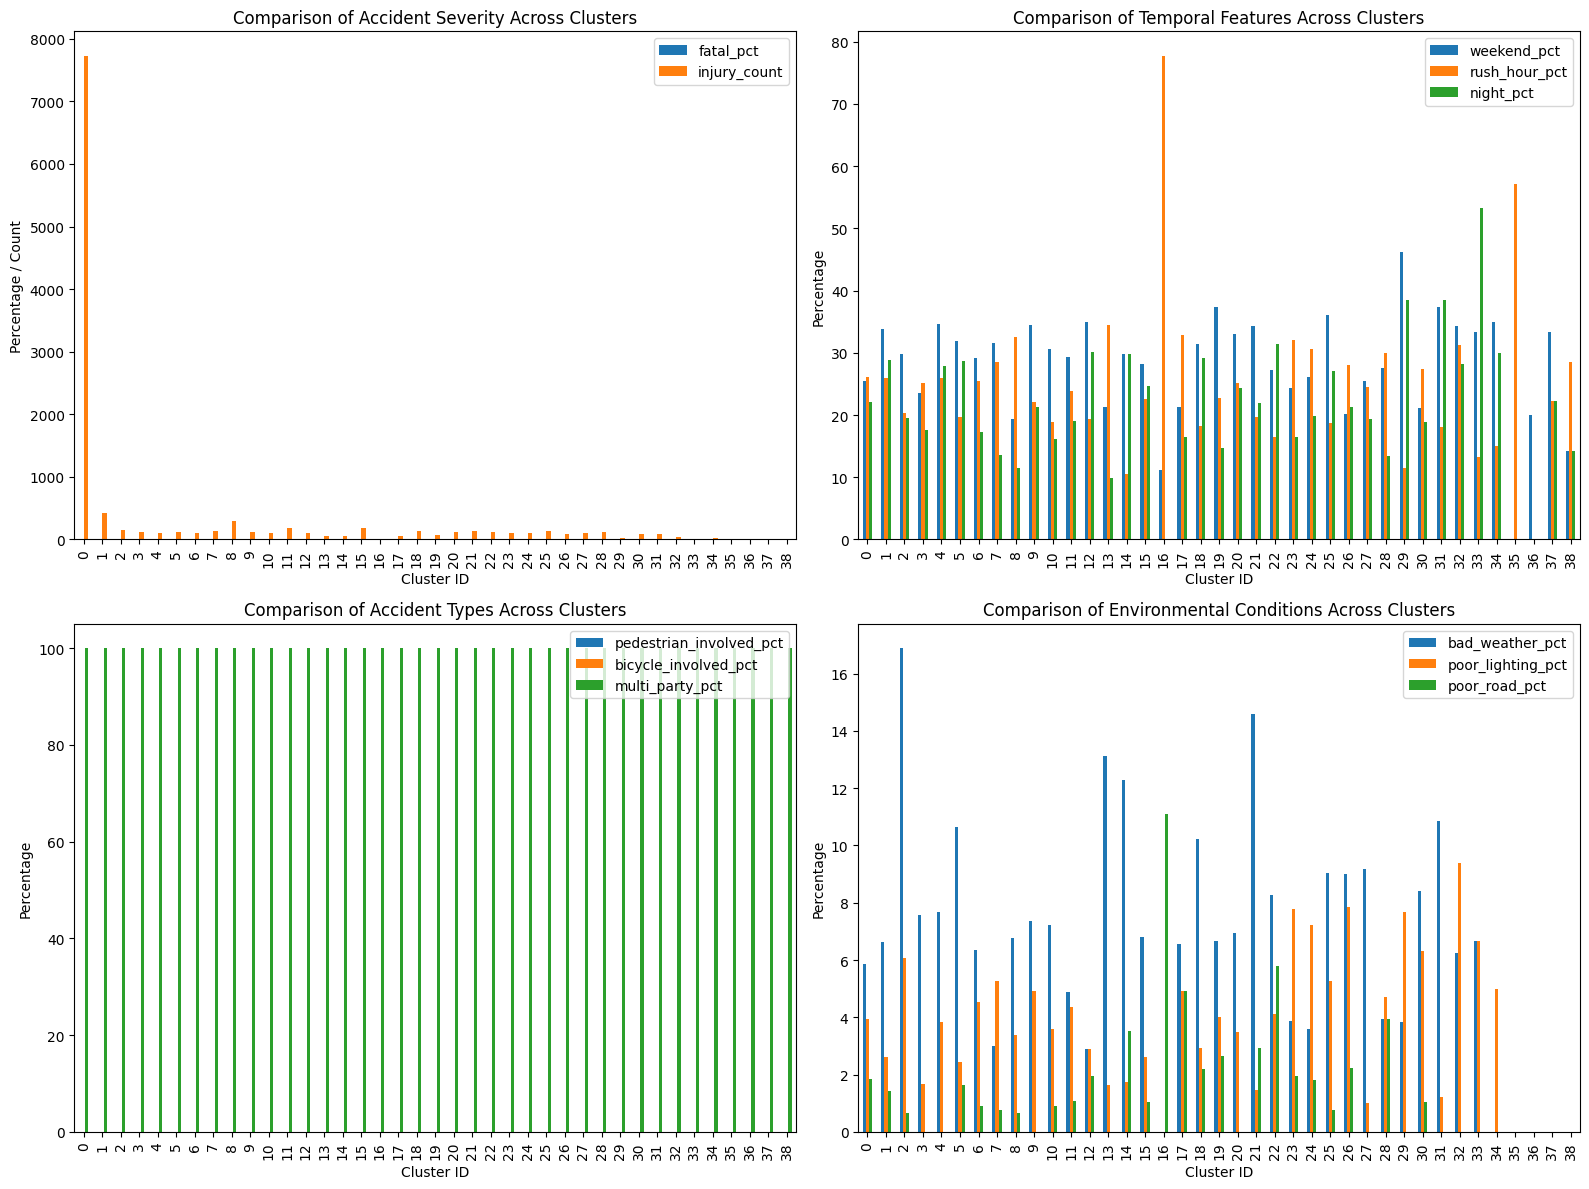


Comprehensive feature analysis completed! All reports saved under results/spatial_analysis/


In [ ]:
# ====== Step 6: Generate Comprehensive Cluster Feature Report ======

def generate_comprehensive_cluster_report(hotspot_latlon, significant_hotspots):
    cluster_report = []
    unique_clusters = set(significant_hotspots['dbscan_cluster']) - {-1}

    for cluster_id in unique_clusters:
        cluster_data = hotspot_latlon[significant_hotspots['dbscan_cluster'] == cluster_id]

        # Basic statistics
        basic_stats = {
            'cluster_id': cluster_id,
            'size': len(cluster_data),
            'center_lat': cluster_data['tb_latitude'].mean(),
            'center_lon': cluster_data['tb_longitude'].mean(),
        }

        # Spatial features
        spatial_features = {
            'neighborhood': cluster_data['analysis_neighborhood'].mode()[0] if 'analysis_neighborhood' in cluster_data and not cluster_data['analysis_neighborhood'].empty else 'N/A',
            'supervisor_district': cluster_data['supervisor_district'].mode()[0] if 'supervisor_district' in cluster_data and not cluster_data['supervisor_district'].empty else 'N/A',
            'police_district': cluster_data['police_district'].mode()[0] if 'police_district' in cluster_data and not cluster_data['police_district'].empty else 'N/A',
            'has_intersection_pct': cluster_data['has_intersection'].mean() * 100 if 'has_intersection' in cluster_data else 0,
            'avg_distance_to_center': cluster_data['distance_to_center'].mean() if 'distance_to_center' in cluster_data else 0,
        }

        # Temporal features
        time_features = {
            'most_common_hour': cluster_data['hour'].mode()[0] if 'hour' in cluster_data and not cluster_data['hour'].empty else 'N/A',
            'most_common_day': cluster_data['day_of_week'].mode()[0] if 'day_of_week' in cluster_data and not cluster_data['day_of_week'].empty else 'N/A',
            'weekend_pct': cluster_data['is_weekend'].mean() * 100 if 'is_weekend' in cluster_data else 0,
            'rush_hour_pct': cluster_data['is_rush_hour'].mean() * 100 if 'is_rush_hour' in cluster_data else 0,
            'most_common_season': cluster_data['season'].mode()[0] if 'season' in cluster_data and not cluster_data['season'].empty else 'N/A',
            'night_pct': (cluster_data['time_of_day'] == 'Night').mean() * 100 if 'time_of_day' in cluster_data else 0,
        }

        # Severity features
        severity_features = {
            'fatal_count': cluster_data['is_fatal'].sum() if 'is_fatal' in cluster_data else 0,
            'injury_count': cluster_data['is_injury'].sum() if 'is_injury' in cluster_data else 0,
            'fatal_pct': cluster_data['is_fatal'].mean() * 100 if 'is_fatal' in cluster_data else 0,
            'avg_casualties': cluster_data['total_casualties'].mean() if 'total_casualties' in cluster_data else 0,
            'max_casualties': cluster_data['total_casualties'].max() if 'total_casualties' in cluster_data else 0,
        }

        # Accident type features
        accident_type_features = {
            'most_common_collision_type': cluster_data['collision_type_simple'].mode()[0] if 'collision_type_simple' in cluster_data and not cluster_data['collision_type_simple'].empty else 'N/A',
            'pedestrian_involved_pct': cluster_data['involves_pedestrian'].mean() * 100 if 'involves_pedestrian' in cluster_data else 0,
            'bicycle_involved_pct': cluster_data['involves_bicycle'].mean() * 100 if 'involves_bicycle' in cluster_data else 0,
            'multi_party_pct': (cluster_data['num_parties'] > 1).mean() * 100 if 'num_parties' in cluster_data else 0,
        }

        # Environmental features
        environmental_features = {
            'most_common_weather': cluster_data['weather_condition'].mode()[0] if 'weather_condition' in cluster_data and not cluster_data['weather_condition'].empty else 'N/A',
            'bad_weather_pct': (cluster_data['weather_condition'] == 'Bad').mean() * 100 if 'weather_condition' in cluster_data else 0,
            'poor_lighting_pct': (cluster_data['lighting_condition'] == 'Poor').mean() * 100 if 'lighting_condition' in cluster_data else 0,
            'poor_road_pct': (cluster_data['road_condition'] == 'Poor').mean() * 100 if 'road_condition' in cluster_data else 0,
            'avg_environmental_risk': cluster_data['environmental_risk_score'].mean() if 'environmental_risk_score' in cluster_data else 0,
        }

        # Driving behavior features
        behavior_features = {
            'most_common_party1_action': cluster_data['party1_move_pre_acc'].mode()[0] if 'party1_move_pre_acc' in cluster_data and not cluster_data['party1_move_pre_acc'].empty else 'N/A',
            'most_common_party2_action': cluster_data['party2_move_pre_acc'].mode()[0] if 'party2_move_pre_acc' in cluster_data and not cluster_data['party2_move_pre_acc'].empty else 'N/A',
            'most_common_at_fault': cluster_data['party_at_fault'].mode()[0] if 'party_at_fault' in cluster_data and not cluster_data['party_at_fault'].empty else 'N/A',
        }

        # Merge all feature dictionaries
        cluster_features = {**basic_stats, **spatial_features, **time_features,
                            **severity_features, **accident_type_features,
                            **environmental_features, **behavior_features}

        cluster_report.append(cluster_features)

    return pd.DataFrame(cluster_report)

# Generate the comprehensive cluster report
cluster_df = generate_comprehensive_cluster_report(hotspot_latlon, significant_hotspots)
cluster_df.to_csv('results/spatial_analysis/comprehensive_cluster_report.csv', index=False)

# Generate a more detailed text-based cluster analysis report
with open('results/spatial_analysis/detailed_cluster_analysis.txt', 'w') as f:
    f.write("=== Multidimensional Cluster Feature Analysis Report ===\n\n")

    for _, row in cluster_df.iterrows():
        f.write(f"Detailed Analysis for Cluster {row['cluster_id']}:\n")
        f.write("=" * 40 + "\n")

        # Basic information
        f.write(f"1. Basic Information\n")
        f.write(f"   - Number of accidents: {row['size']}\n")
        f.write(f"   - Center location: ({row['center_lat']:.6f}, {row['center_lon']:.6f})\n")
        f.write(f"   - Neighborhood: {row['neighborhood']}\n\n")

        # Severity analysis
        f.write(f"2. Accident Severity\n")
        f.write(f"   - Fatal accidents: {row['fatal_count']} ({row['fatal_pct']:.1f}%)\n")
        f.write(f"   - Injury accidents: {row['injury_count']}\n")
        f.write(f"   - Average casualties: {row['avg_casualties']:.2f}\n")
        f.write(f"   - Maximum casualties: {row['max_casualties']}\n\n")

        # Temporal analysis
        f.write(f"3. Temporal Features\n")
        f.write(f"   - Most common hour: {row['most_common_hour']}h\n")
        f.write(f"   - Most common day: {row['most_common_day']}\n")
        f.write(f"   - Weekend accident percentage: {row['weekend_pct']:.1f}%\n")
        f.write(f"   - Rush hour accident percentage: {row['rush_hour_pct']:.1f}%\n")
        f.write(f"   - Nighttime accident percentage: {row['night_pct']:.1f}%\n\n")

        # Accident type analysis
        f.write(f"4. Accident Type\n")
        f.write(f"   - Most common collision type: {row['most_common_collision_type']}\n")
        f.write(f"   - Pedestrian-involved percentage: {row['pedestrian_involved_pct']:.1f}%\n")
        f.write(f"   - Bicycle-involved percentage: {row['bicycle_involved_pct']:.1f}%\n")
        f.write(f"   - Multi-party accident percentage: {row['multi_party_pct']:.1f}%\n\n")

        # Environmental conditions
        f.write(f"5. Environmental Conditions\n")
        f.write(f"   - Most common weather: {row['most_common_weather']}\n")
        f.write(f"   - Bad weather percentage: {row['bad_weather_pct']:.1f}%\n")
        f.write(f"   - Poor lighting percentage: {row['poor_lighting_pct']:.1f}%\n")
        f.write(f"   - Poor road condition percentage: {row['poor_road_pct']:.1f}%\n")
        f.write(f"   - Average environmental risk score: {row['avg_environmental_risk']:.2f}\n\n")

        # Risk assessment
        risk_score = (
            row['fatal_pct'] * 0.3 +
            row['night_pct'] * 0.2 +
            row['pedestrian_involved_pct'] * 0.2 +
            row['avg_environmental_risk'] * 0.15 +
            row['rush_hour_pct'] * 0.15
        )

        f.write(f"6. Comprehensive Risk Assessment\n")
        f.write(f"   - Overall risk score: {risk_score:.2f}\n")
        f.write(f"   - Risk level: {'High' if risk_score > 60 else 'Medium' if risk_score > 30 else 'Low'}\n")
        f.write("\n" + "=" * 40 + "\n\n")

# Create feature comparison visualizations for clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accident severity comparison
ax = axes[0, 0]
cluster_df.plot(x='cluster_id', y=['fatal_pct', 'injury_count'], kind='bar', ax=ax)
ax.set_title('Comparison of Accident Severity Across Clusters')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Percentage / Count')

# 2. Temporal features comparison
ax = axes[0, 1]
cluster_df.plot(x='cluster_id', y=['weekend_pct', 'rush_hour_pct', 'night_pct'], kind='bar', ax=ax)
ax.set_title('Comparison of Temporal Features Across Clusters')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Percentage')

# 3. Accident type comparison
ax = axes[1, 0]
cluster_df.plot(x='cluster_id', y=['pedestrian_involved_pct', 'bicycle_involved_pct', 'multi_party_pct'], kind='bar', ax=ax)
ax.set_title('Comparison of Accident Types Across Clusters')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Percentage')

# 4. Environmental conditions comparison
ax = axes[1, 1]
cluster_df.plot(x='cluster_id', y=['bad_weather_pct', 'poor_lighting_pct', 'poor_road_pct'], kind='bar', ax=ax)
ax.set_title('Comparison of Environmental Conditions Across Clusters')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Percentage')

plt.tight_layout()
plt.savefig('results/spatial_analysis/cluster_features_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nComprehensive feature analysis completed! All reports saved under results/spatial_analysis/")
